# Clase bonus: Ejemplo de un Análisis Exploratorio de Datos (EDA)

<img src="../img/sergio_portrait_square.png" alt="Sergio Benito" align="right" width="100">

- **Autor:** Sergio Benito Martín
- **Contacto:** pontia@sergiobenito.com
- **Última actualización:** 23/11/2025

## Recursos útiles
+ [Medium - A Comprehensive Guide on Exploratory Data Analysis (EDA)](https://medium.com/@pabbakavya123/a-comprehensive-guide-on-exploratory-data-analysis-eda-ab38f33d6abc)
+ [Medium - A Data Scientist’s Essential Guide to Exploratory Data Analysis](https://medium.com/data-science/a-data-scientists-essential-guide-to-exploratory-data-analysis-25637eee0cf6)
+ [Medium - Mastering Exploratory Data Analysis (EDA): Everything You Need To Know](https://medium.com/data-and-beyond/mastering-exploratory-data-analysis-eda-everything-you-need-to-know-7e3b48d63a95)
+ [Towards Data Science - An Extensive Step by Step Guide to Exploratory Data Analysis](https://towardsdatascience.com/an-extensive-guide-to-exploratory-data-analysis-ddd99a03199e/)

## Objetivo 

Este notebook tiene como objetivo ilustrar paso a paso un Análisis Exploratorio de Datos (EDA) utilizando un dataset real sobre enfermedades cardíacas (*heart disease*).

## ⚙️ 0. Configuración del notebook 

### Carga de librerías

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import seaborn as sns

from plotly.subplots import make_subplots

### Definición de constantes

In [71]:
# Paths
PATH_DIRECTORIO_DATOS = "../data"
PATH_DATASET_HEART = f"{PATH_DIRECTORIO_DATOS}/heart_disease.csv"

# Listas de variables
LIST_CAT_COLS = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
LIST_NUM_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
VARIABLE_TARGET = 'target'

# Preprocesados
DICT_MAP_TARGET = {0: 'No enfermedad', 1: 'Con enfermedad'}

### Definimos las paletas de color

In [61]:
# Mostramos las paletas de colores que tiene Plotly
px.colors.qualitative.swatches()

In [84]:
# Definimos una paleta de color según los valores del target
LIST_PALETA_COLOR = px.colors.qualitative.T10

# Asignamos los índices de dicha paleta a los valores del target
# 'No enfermedad' -> color verde (porque es buen indicador)
# 'Con enfermedad' -> color rojo (porque es mal indicador)
DICT_PALETA_COLOR_TARGET = {'No enfermedad': LIST_PALETA_COLOR[4], 'Con enfermedad': LIST_PALETA_COLOR[2]}

### Definición de funciones

In [117]:
def plot_matriz_correlacion(df: pd.DataFrame, variable_dependiente:str = None):
    """Genera una matriz de correlación interactiva utilizando Plotly.
    
    Crea una visualización de mapa de calor que muestra las correlaciones entre todas
    las variables numéricas del DataFrame, con anotaciones de los valores exactos.
    Adicionalmente, imprime un ranking de correlaciones con la variable dependiente
    especificada.
    
    Args:
        df (pd.DataFrame): DataFrame que contiene las variables numéricas para analizar.
        variable_dependiente (str, optional): Nombre de la columna que se considera la variable 
                                             dependiente, cuyas correlaciones se mostrarán ordenadas.
                                             Si es None, no se imprimirán correlaciones específicas.
    
    Returns:
        plotly.graph_objs._figure.Figure: Objeto Figure de Plotly con la matriz de correlación.
    
    Example:
        >>> fig = plot_matriz_correlacion(df_preprocessed[LIST_NUM_COLS], "age")
    """
    
    # Crear matriz de correlación para visualizar relaciones entre variables con Plotly
    correlation_matrix = df.corr()

    # Crear un mapa de calor interactivo con Plotly
    fig = px.imshow(
        correlation_matrix,
        text_auto='.2f',                    # Mostrar valores numéricos con 2 decimales
        color_continuous_scale='RdBu_r',    # Esquema de colores (rojo-blanco-azul invertido)
        zmin=-1, zmax=1,                    # Rango de valores
        aspect="auto",                      # Ajustar aspecto automáticamente
        title='Matriz de Correlación entre Variables'
    )

    # Mejorar el diseño
    fig.update_layout(
        width=800, 
        height=700,
        coloraxis_colorbar=dict(
            title="Coeficiente<br>de Correlación",
            thicknessmode="pixels", thickness=20,
            lenmode="pixels", len=500,
            yanchor="top", y=1,
            ticks="outside"
        ),
        font=dict(size=12),
    )

    # Identificar y mostrar las correlaciones más fuertes con la variable dependiente, si está definida
    if variable_dependiente:
        correlaciones_con_variable_dependiente = correlation_matrix[variable_dependiente].sort_values(ascending=False)

        # Imprimir correlaciones con la variable dependiente
        print(f"\nCorrelaciones con '{variable_dependiente}':")
        print(correlaciones_con_variable_dependiente)

    return fig

## 📊 1. Carga y exploración inicial de los datos

In [3]:
# Cargar el dataset
df = pd.read_csv(PATH_DATASET_HEART)

### 🔍 Primer vistazo al dataset

In [4]:
# Primeras filas
print("Primeras filas del dataframe:")
df.head()

Primeras filas del dataframe:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# Se muestran los tipos de variables del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [65]:
# Copiamos el dataframe para no perder el original
df_preprocessed = df.copy()

In [66]:
# Se convierten las variables que deberían ser categóricas a formato str
df_preprocessed[LIST_CAT_COLS] = df[LIST_CAT_COLS].astype(str)

In [67]:
# Se muestran los tipos de variables del dataset una vez convertidas
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    object 
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 33.3+ KB


### 📈 Estadísticos descriptivos

In [68]:
# Estadísticos de las variables numéricas
df_preprocessed.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2
target,303.0,0.544554,0.498835,0.0,0.0,1.0,1.0,1.0


In [69]:
# Estadísticos de las variables categóricas
df_preprocessed.describe(include='object').transpose()

,count,unique,top,freq
sex,303,2,1,207
cp,303,4,0,143
fbs,303,2,0,258
restecg,303,3,1,152
exang,303,2,0,204
slope,303,3,2,142
ca,303,5,0,175
thal,303,4,2,166


### Convertimos los valores numéricos de la columna target a tipo objeto
Esta transformación es para facilitar las próximas visualizaciones y análisis, se puede abordar o no. Usamos el diccionario previamente almacenado en una constante:

```python
DICT_MAP_TARGET = {0: 'No enfermedad', 1: 'Con enfermedad'}
```

In [72]:
df_preprocessed[VARIABLE_TARGET] = df_preprocessed[VARIABLE_TARGET].map(DICT_MAP_TARGET)

## 🔎 2. Análisis de valores extraños

### 🚫 Valores nulos

In [73]:
print("Valores vacíos por cada columna:")
print(df_preprocessed.isna().sum())

Valores vacíos por cada columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### Valores duplicados

In [143]:
print(f"Filas con valores duplicados: {df_preprocessed.duplicated().sum()}")

Filas con valores duplicados: 1


In [142]:
# Mostramos las filas duplicadas
df_preprocessed.loc[df_preprocessed.duplicated(keep=False)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,Con enfermedad
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,Con enfermedad


In [145]:
# Gestionamos los valores duplicados
# En este caso decidimos borrarlos
df_preprocessed = df_preprocessed.drop_duplicates()

## 🌐 3. Análisis univariado

### ⭐ Variables numéricas

In [146]:
# Se muestran las distribuciones de las variables numéricas
for col in LIST_NUM_COLS:
    fig = ff.create_distplot(
        [df_preprocessed[col]],
        [col],
        show_hist=True,
        show_curve=True,
        show_rug=False
    )
    fig.update_layout(
        title=f"Distribución variable: {col}"
    )
    fig.show()

### 📃 Variables categóricas

In [147]:
for col in LIST_CAT_COLS:
    fig = make_subplots()

In [148]:
for col in LIST_CAT_COLS:
    fig = px.histogram(
        df_preprocessed,
        x=col,
        text_auto=True,
        title=f'Distribución de la variable categórica: {col}',
        color_discrete_sequence=['mediumturquoise']
    )
    fig.show()

## 📊 4. Variable objetivo: `target`

In [149]:
# Creamos un dataframe que agregue el recuento de valores de la variable objetivo
df_target_counts = df_preprocessed[VARIABLE_TARGET].value_counts().reset_index()
df_target_counts.columns = [VARIABLE_TARGET, 'count']

# Mostramos la distribución de la variable objetivo
fig_count = px.bar(
    df_target_counts,
    x=VARIABLE_TARGET,
    y='count',
    text='count',
    title=f'Distribución de la variable objetivo ({VARIABLE_TARGET})',
    color=VARIABLE_TARGET,
    color_discrete_map=DICT_PALETA_COLOR_TARGET)
fig_count.update_traces(hovertemplate='%{label}: %{value:}')
fig_count.show()

In [150]:
# Creamos un dataframe que agregue las frecuencias relativas de valores de la variable objetivo
df_target_counts = df_preprocessed[VARIABLE_TARGET].value_counts(normalize=True).reset_index()
df_target_counts.columns = [VARIABLE_TARGET, 'proportion']

# Mostramos la distribución de la variable objetivo en proporciones
fig_prop = px.pie(
    df_target_counts,
    names=VARIABLE_TARGET,
    values='proportion',
    title=f'Distribución proporcional de la variable objetivo ({VARIABLE_TARGET})',
    color=VARIABLE_TARGET,
    color_discrete_map=DICT_PALETA_COLOR_TARGET,
    hole=0.4
)
fig_prop.update_traces(hovertemplate='%{label}: %{value:.2%}')
fig_prop.show()

In [151]:
# Crear subplots con tipos específicos
fig = make_subplots(
	rows=1, cols=2, 
	subplot_titles=("Frecuencias absolutas", "Frecuencias relativas"), 
	specs=[[{"type": "bar"}, {"type": "pie"}]]
)

# Añadir las trazas del gráfico de barras
for trace in fig_count.data:
	fig.add_trace(trace, row=1, col=1)

# Añadir las trazas del gráfico de sectores
for trace in fig_prop.data:
	fig.add_trace(trace, row=1, col=2)

# Actualizar layout
fig.update_layout(
	title_text=f"Distribución de la variable objetivo: {VARIABLE_TARGET}",
	showlegend=False
)

fig.show()

## 🔄 5. Análisis bivariado: relación con la variable objetivo
### Variables numéricas

In [152]:
for col in LIST_NUM_COLS:
    fig = px.box(
        df_preprocessed,
        x=VARIABLE_TARGET,
        y=col,
        color=VARIABLE_TARGET,
        title=f'{col} según presencia de enfermedad',
        color_discrete_map=DICT_PALETA_COLOR_TARGET
    )
    fig.show()

### Variables categóricas

In [153]:
for col in LIST_CAT_COLS:
    
    # Calcular proporciones de enfermedad según la variable categórica
    df_prop = pd.crosstab(df_preprocessed[col], df_preprocessed[VARIABLE_TARGET], normalize='index').reset_index()
    #prop_df.columns = [col, 'No enfermedad', 'Con enfermedad']

    # Crear gráfico de barras apiladas para mostrar proporciones
    fig = go.Figure()

    # Iteramos por las clases del target a través de los valores del diccionario donde las definimos
    for clase_seleccionada in DICT_MAP_TARGET.values():
        fig.add_trace(go.Bar(
            x=df_prop[col],
            y=df_prop[clase_seleccionada],
            text=df_prop[clase_seleccionada],
            texttemplate='%{text:.2%}',
            name=clase_seleccionada,
            marker_color=DICT_PALETA_COLOR_TARGET[clase_seleccionada]
        ))
        
    # Actualizamos el layout
    fig.update_layout(
        barmode='stack',
        title=f'Proporción de enfermedad según {col}',
        xaxis_title=col,
        yaxis_title='Proporción'
    )
    fig.show()

### Análisis multivariante

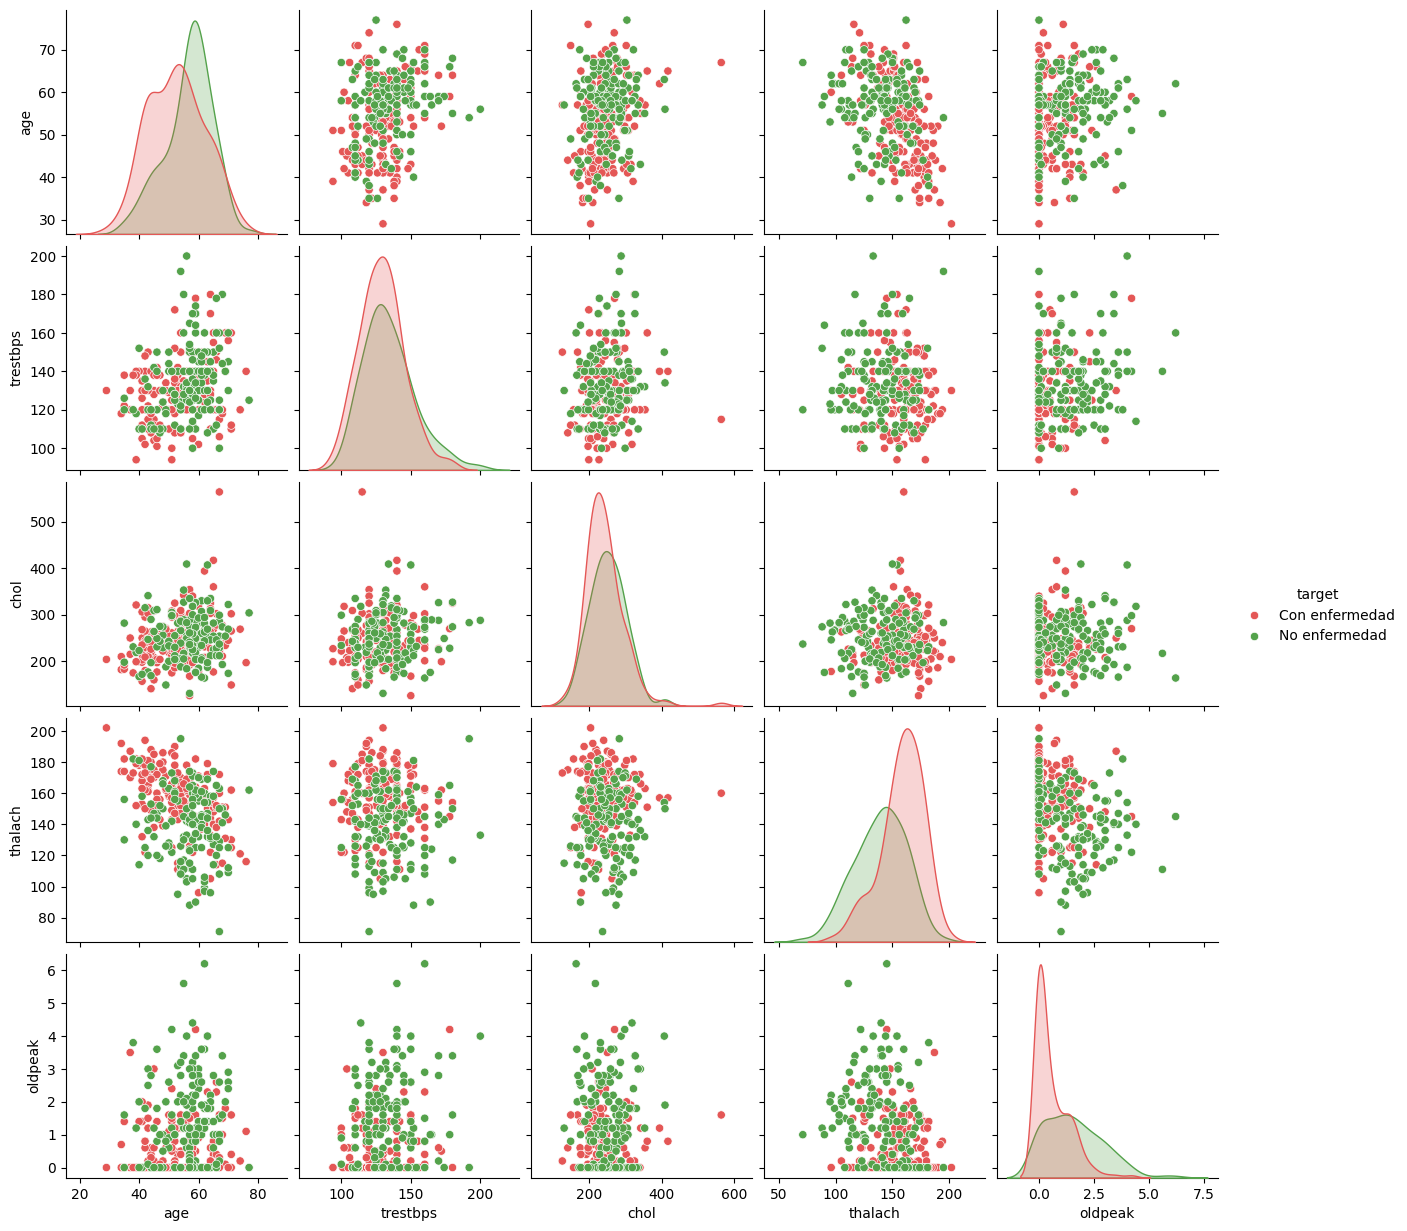

In [154]:
sns.pairplot(df_preprocessed, hue=VARIABLE_TARGET, palette=DICT_PALETA_COLOR_TARGET)

## 🤔 6. Matriz de correlación

In [155]:
# Calculamos la correlación entre las variables
corr = df_preprocessed[LIST_NUM_COLS].corr().round(2)
z = corr.values
x = list(corr.columns)
y = list(corr.index)

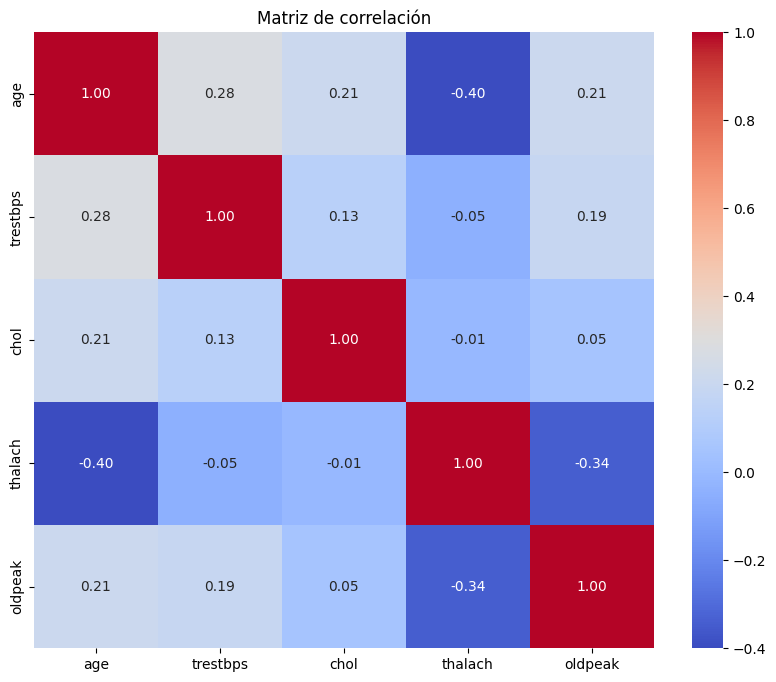

In [156]:
# Mostramos la matriz de correlación con Seaborn y Matplotlib
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

In [157]:
# Mostramos la matriz de correlación con la función definida
fig = plot_matriz_correlacion(df_preprocessed[LIST_NUM_COLS])
fig.show()

In [158]:
 # Mostramos la matriz de correlación con Plotly usando figure factory
fig = ff.create_annotated_heatmap(z, x=x, y=y, colorscale='RdBu', showscale=True, zmin=-1, zmax=1)
fig.update_layout(title_text='Matriz de correlación entre variables')
fig.show()

## 🔹 7. Conclusiones preliminares

In [159]:
print("\nCONCLUSIONES PRELIMINARES:")
print("- La mayoría de las personas en el dataset tienen enfermedad cardíaca (target=1).")
print("- Edad, colesterol, frecuencia cardíaca y depresión del ST tienen relación con la enfermedad.")
print("- No hay valores nulos, lo que facilita el análisis inicial.")
print("- Variables categóricas como cp, exang y slope muestran diferencias claras según la presencia de enfermedad.")
print("- Esta fase permite detectar patrones, errores o ideas para transformaciones futuras.")


CONCLUSIONES PRELIMINARES:
- La mayoría de las personas en el dataset tienen enfermedad cardíaca (target=1).
- Edad, colesterol, frecuencia cardíaca y depresión del ST tienen relación con la enfermedad.
- No hay valores nulos, lo que facilita el análisis inicial.
- Variables categóricas como cp, exang y slope muestran diferencias claras según la presencia de enfermedad.
- Esta fase permite detectar patrones, errores o ideas para transformaciones futuras.


## 🏎️ 8. Bonus. Auto-EDA
Se pueden utilizar herramientas que realizan un análisis exploratorio de manera rápida, modo low-code, como es `YData Profiling`. Habría que instalarlo en el entorno usando:
```bash
uv pip install ydata-profiling
```

Aquí su documentación oficial: [YData Profiling](https://docs.profiling.ydata.ai/latest/)

In [164]:
from ydata_profiling import ProfileReport

In [161]:
profile = ProfileReport(df, title="EDA Automático - Heart Disease")

In [163]:
profile.to_notebook_iframe()

Render HTML: 100%|██████████| 1/1 [00:00<00:00,  1.31it/s]
